# Tugas 2 PMML

**Nama:** Taufik Nurrizqi  

**NIM:** 25/573844/PPA/07225

**Mata Kuliah:** Pembelajaran Mesin Mendalam Lanjut (PMML)  

**Program:** Magister Kecerdasan Artifisial, UGM


Notebook ini berisi **satu file** yang memuat:
baseline + 5 skenario (A: L1, B: L2, C: Dropout, D: Early Stopping, E: L1 + Dropout).
Setiap skenario dimulai dari kode baseline yang sama (bukan dari skenario lain),
kecuali Skenario E yang sengaja menggabungkan Skenario A dan C.



## 0. Import library dan konfigurasi

In [1]:
import os, json, io, random
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Flatten, Dense, Dropout
from keras.regularizers import L1, L2
from keras.callbacks import EarlyStopping
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# --- Konfigurasi umum ---
SEED = 42                 # seed agar hasil dapat direproduksi
EPOCHS = 10               # epoch untuk baseline dan skenario A, B, C, E
EPOCHS_ES = 50            # batas maksimum epoch untuk skenario D (training akan berhenti lebih awal)
BATCH_SIZE = 100
HASIL_DIR = "hasil"       # folder keluaran
os.makedirs(HASIL_DIR, exist_ok=True)

# --- Hyperparameter yang dipilih
L1_RATE = 0.001           # Skenario A (dan E)
L2_RATE = 0.001           # Skenario B
DROPOUT_RATE = 0.2        # Skenario C (dan E)
PATIENCE = 3              # Skenario D

def atur_seed(seed=SEED):
    """Set seed Python, NumPy, dan TensorFlow/Keras agar eksperimen dapat diulang."""
    random.seed(seed)
    np.random.seed(seed)
    keras.utils.set_random_seed(seed)

atur_seed()
print("Versi Keras:", keras.__version__)

Versi Keras: 3.13.2


## 1. Load data dan preprocessing
MNIST (60.000 train + 10.000 test) digabung menjadi 70.000 citra, lalu dibagi
**70% train (49.000) / 20% validasi (14.000) / 10% test (7.000)** dengan stratifikasi kelas.
Karena validasi = 20% dari *seluruh* data, maka setelah test (10%) dipisahkan,
validasi diambil 14.000/63.000 dari sisa data latih.

In [2]:
def muat_mnist():
    """Load MNIST lewat keras.datasets. Jika tidak ada internet, pakai file lokal mnist.npz (opsional)."""
    try:
        return mnist.load_data()
    except Exception as err:
        if os.path.exists("mnist.npz"):
            print("Download gagal, memakai mnist.npz lokal:", type(err).__name__)
            d = np.load("mnist.npz")
            return (d["x_train"], d["y_train"]), (d["x_test"], d["y_test"])
        raise

(x_a, y_a), (x_b, y_b) = muat_mnist()
X_all = np.concatenate([x_a, x_b]).reshape(-1, 28, 28, 1).astype("float32") / 255   # reshape + normalisasi
y_all = np.concatenate([y_a, y_b])

# 1) memisahkan test 10%
X_tv, X_test, y_tv, y_test = train_test_split(X_all, y_all, test_size=0.10, random_state=SEED, stratify=y_all)
# 2) mengambil validasi dari sisa 90%, sehingga totalnya 20% dari seluruh data
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=14000/63000, random_state=SEED, stratify=y_tv)

# One-hot encoding label
Y_train = to_categorical(y_train, 10)
Y_val   = to_categorical(y_val, 10)
Y_test  = to_categorical(y_test, 10)

print("X_train:", X_train.shape, "| Y_train:", Y_train.shape)
print("X_val  :", X_val.shape,   "| Y_val  :", Y_val.shape)
print("X_test :", X_test.shape,  "| Y_test :", Y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
X_train: (49000, 28, 28, 1) | Y_train: (49000, 10)
X_val  : (14000, 28, 28, 1) | Y_val  : (14000, 10)
X_test : (7000, 28, 28, 1) | Y_test : (7000, 10)


## 2. Fungsi bantu (dokumentasi hasil)
Fungsi di bawah hanya menyimpan keluaran (ringkasan model, performa, grafik). Definisi model,
`compile`, `fit`, dan `evaluate` tetap ditulis eksplisit di setiap skenario.

In [3]:
HASIL = {}   # menampung angka setiap skenario untuk tabel perbandingan akhir

def ringkasan_model(model, kode):
    """Cetak model.summary() dan simpan ke Scenario_X_model_summary.txt."""
    baris = []
    model.summary(print_fn=lambda s, **kw: baris.append(s))
    teks = "\n".join(baris)
    print(teks)
    with open(f"{HASIL_DIR}/Scenario_{kode}_model_summary.txt", "w", encoding="utf-8") as f:
        f.write(teks + "\n")

def plot_loss(history, kode, judul, epoch_berhenti=None):
    """Grafik training loss (merah) vs validation loss (biru); simpan ke Scenario_X_loss_chart.png."""
    loss, val_loss = history.history["loss"], history.history["val_loss"]
    ep = range(1, len(loss) + 1)
    with plt.rc_context({"font.size": 12, "axes.titlesize": 14, "legend.fontsize": 11}):
        plt.figure(figsize=(8, 4.2))
        plt.plot(ep, loss, "r-o", markersize=4, label="Training Loss")
        plt.plot(ep, val_loss, "b-o", markersize=4, label="Validation Loss")
        if epoch_berhenti is not None:   # khusus Early Stopping: tandai epoch terbaik dan epoch berhenti
            terbaik = int(np.argmin(val_loss)) + 1
            plt.axvline(terbaik, color="green", linestyle=":", label=f"Val loss terendah (epoch {terbaik})")
            plt.axvline(epoch_berhenti, color="black", linestyle="--", label=f"Training berhenti (epoch {epoch_berhenti})")
        plt.title(f"Model Loss - {judul}")
        plt.xlabel("Epoch"); plt.ylabel("Loss")
        plt.grid(True); plt.legend(loc="upper right")
        plt.savefig(f"{HASIL_DIR}/Scenario_{kode}_loss_chart.png", dpi=150, bbox_inches="tight")
        plt.show()

def simpan_performa(kode, nama, model, history, test_loss, test_acc, parameter, catatan=""):
    """Simpan Scenario_X_performance.txt dan catat angka ke dict HASIL."""
    h = history.history
    train_acc, val_acc = h["acc"][-1], h["val_acc"][-1]
    # Akurasi training dalam mode inferensi (dropout nonaktif) agar gap train-val adil untuk semua skenario
    _, train_acc_eval = model.evaluate(X_train, Y_train, verbose=0)
    gap = (train_acc_eval - val_acc) * 100
    d = dict(kode=kode, nama=nama, parameter=parameter,
             epoch_jalan=len(h["loss"]),
             train_acc=train_acc, val_acc=val_acc, test_acc=test_acc,
             train_acc_eval=train_acc_eval, gap_pp=gap,
             train_loss=h["loss"][-1], val_loss=h["val_loss"][-1], test_loss=test_loss,
             val_loss_min=min(h["val_loss"]), epoch_val_loss_min=int(np.argmin(h["val_loss"])) + 1,
             total_params=int(model.count_params()),
             trainable_params=int(sum(np.prod(w.shape) for w in model.trainable_weights)),
             catatan=catatan)
    HASIL[kode] = d
    teks = (f"Skenario {kode} - {nama}\n"
            f"Parameter                      : {parameter}\n"
            f"Jumlah epoch yang dijalankan   : {d['epoch_jalan']}\n"
            f"Training accuracy (epoch akhir): {train_acc*100:.2f}%\n"
            f"Validation accuracy (akhir)    : {val_acc*100:.2f}%\n"
            f"Test accuracy                  : {test_acc*100:.2f}%\n"
            f"Training accuracy (mode eval)  : {train_acc_eval*100:.2f}%\n"
            f"Gap train(eval) - validasi     : {gap:.2f} poin persen\n"
            f"Training loss / Val loss / Test loss (akhir): {d['train_loss']:.4f} / {d['val_loss']:.4f} / {test_loss:.4f}\n"
            f"Val loss terendah              : {d['val_loss_min']:.4f} (epoch {d['epoch_val_loss_min']})\n"
            f"Total parameters               : {d['total_params']:,}\n"
            f"Trainable parameters           : {d['trainable_params']:,}\n")
    if catatan:
        teks += f"Catatan                        : {catatan}\n"
    print(teks)
    with open(f"{HASIL_DIR}/Scenario_{kode}_performance.txt", "w", encoding="utf-8") as f:
        f.write(teks)

## 3. Pemilihan hyperparameter (pilot, opsional)
Nilai `L1_RATE`, `L2_RATE`, `DROPOUT_RATE`, dan `PATIENCE` pada bagian konfigurasi dipilih lewat uji pilot
singkat pada kandidat yang direkomendasikan di soal. Pemilihan memakai **akurasi validasi** (bukan test).
Pilot ini bukan skenario tambahan dan dimatikan secara default (`JALANKAN_PILOT = False`) agar hasil utama tetap 5 skenario + baseline.

In [4]:
JALANKAN_PILOT = False

def _pilot(nama, layers, epochs=EPOCHS, cb=None):
    atur_seed()
    m = Sequential(layers)
    m.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["acc"])
    h = m.fit(X_train, Y_train, epochs=epochs, batch_size=BATCH_SIZE,
              validation_data=(X_val, Y_val), verbose=0, callbacks=cb)
    print(f"{nama:22s} epoch={len(h.history['loss']):2d}  val_acc={h.history['val_acc'][-1]*100:.2f}%")

if JALANKAN_PILOT:
    for r in (0.001, 0.01, 0.1):
        _pilot(f"L1 rate={r}", [Flatten(), Dense(64, activation="relu", kernel_regularizer=L1(r)),
                                Dense(10, activation="softmax", kernel_regularizer=L1(r))])
        _pilot(f"L2 rate={r}", [Flatten(), Dense(64, activation="relu", kernel_regularizer=L2(r)),
                                Dense(10, activation="softmax", kernel_regularizer=L2(r))])
    for r in (0.2, 0.3, 0.5):
        _pilot(f"Dropout rate={r}", [Flatten(), Dense(64, activation="relu"), Dropout(r),
                                     Dense(10, activation="softmax")])
    for p in (2, 3, 5):
        _pilot(f"EarlyStop patience={p}", [Flatten(), Dense(64, activation="relu"), Dense(10, activation="softmax")],
               epochs=EPOCHS_ES, cb=[EarlyStopping(monitor="val_loss", patience=p)])

## 4. Baseline (replikasi kode slide halaman 14-23)
Flatten -> Dense(64, relu) -> Dense(10, softmax); Adam, categorical crossentropy, 10 epoch, batch 100.

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 50,890 (198.79 KB)
 Trainable params: 50,890 (198.79 KB)
 Non-trainable params: 0 (0.00 B)

Epoch 1/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8838 - loss: 0.4253 - val_acc: 0.9301 - val_loss: 0.2461
Epoch 2/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9

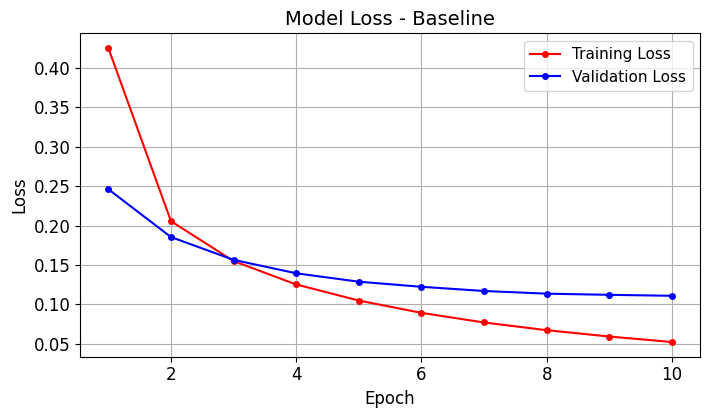

Skenario Baseline - Baseline (tanpa learning strategy)
Parameter                      : -
Jumlah epoch yang dijalankan   : 10
Training accuracy (epoch akhir): 98.59%
Validation accuracy (akhir)    : 96.62%
Test accuracy                  : 96.94%
Training accuracy (mode eval)  : 98.57%
Gap train(eval) - validasi     : 1.94 poin persen
Training loss / Val loss / Test loss (akhir): 0.0523 / 0.1110 / 0.1071
Val loss terendah              : 0.1110 (epoch 10)
Total parameters               : 50,890
Trainable parameters           : 50,890



In [5]:
atur_seed()
model_base = Sequential()
model_base.add(Flatten())
model_base.add(Dense(64, activation="relu"))
model_base.add(Dense(10, activation="softmax"))
model_base.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["acc"])
model_base.build(input_shape=(None, 28, 28, 1))
ringkasan_model(model_base, "Baseline")

hist_base = model_base.fit(X_train, Y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                           validation_data=(X_val, Y_val))
loss_base, acc_base = model_base.evaluate(X_test, Y_test)
print("Akurasi Testing Baseline:", acc_base)

plot_loss(hist_base, "Baseline", "Baseline")
simpan_performa("Baseline", "Baseline (tanpa learning strategy)", model_base, hist_base,
                loss_base, acc_base, parameter="-")

## 5. Skenario A - L1 Regularization
`kernel_regularizer=L1(...)` pada kedua layer Dense. Catatan: pada Keras 3 argumen bernama `l1`
(bukan `l`), sehingga ditulis `L1(l1=...)`.

Model: "sequential_1"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 50,890 (198.79 KB)
 Trainable params: 50,890 (198.79 KB)
 Non-trainable params: 0 (0.00 B)

Epoch 1/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8649 - loss: 1.2036 - val_acc: 0.8994 - val_loss: 0.8137
Epoch 2/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0

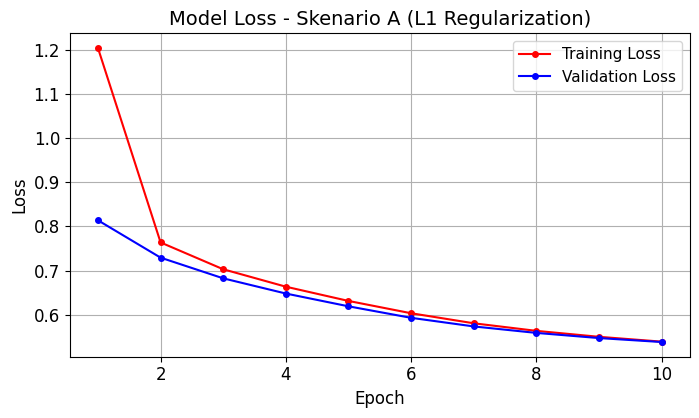

Skenario A - L1 Regularization
Parameter                      : L1 rate = 0.001
Jumlah epoch yang dijalankan   : 10
Training accuracy (epoch akhir): 93.57%
Validation accuracy (akhir)    : 93.42%
Test accuracy                  : 93.26%
Training accuracy (mode eval)  : 93.73%
Gap train(eval) - validasi     : 0.31 poin persen
Training loss / Val loss / Test loss (akhir): 0.5392 / 0.5383 / 0.5414
Val loss terendah              : 0.5383 (epoch 10)
Total parameters               : 50,890
Trainable parameters           : 50,890
Catatan                        : Nilai loss sudah termasuk penalti regularisasi L1 (tidak sebanding langsung dengan loss baseline).



In [6]:
atur_seed()
model_A = Sequential()
model_A.add(Flatten())
model_A.add(Dense(64, activation="relu", kernel_regularizer=L1(l1=L1_RATE)))
model_A.add(Dense(10, activation="softmax", kernel_regularizer=L1(l1=L1_RATE)))
model_A.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["acc"])
model_A.build(input_shape=(None, 28, 28, 1))
ringkasan_model(model_A, "A")

hist_A = model_A.fit(X_train, Y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                     validation_data=(X_val, Y_val))
loss_A, acc_A = model_A.evaluate(X_test, Y_test)
print("Akurasi Testing Skenario A (L1):", acc_A)

plot_loss(hist_A, "A", "Skenario A (L1 Regularization)")
simpan_performa("A", "L1 Regularization", model_A, hist_A, loss_A, acc_A,
                parameter=f"L1 rate = {L1_RATE}",
                catatan="Nilai loss sudah termasuk penalti regularisasi L1 (tidak sebanding langsung dengan loss baseline).")

## 6. Skenario B - L2 Regularization

Model: "sequential_2"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 50,890 (198.79 KB)
 Trainable params: 50,890 (198.79 KB)
 Non-trainable params: 0 (0.00 B)

Epoch 1/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8830 - loss: 0.5398 - val_acc: 0.9280 - val_loss: 0.3681
Epoch 2/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0

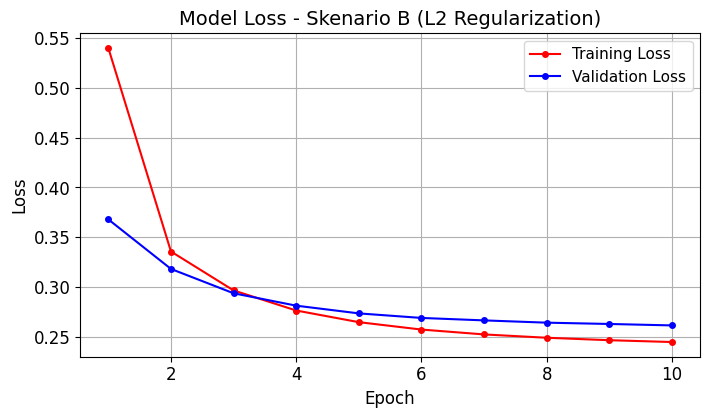

Skenario B - L2 Regularization
Parameter                      : L2 rate = 0.001
Jumlah epoch yang dijalankan   : 10
Training accuracy (epoch akhir): 96.69%
Validation accuracy (akhir)    : 95.94%
Test accuracy                  : 96.23%
Training accuracy (mode eval)  : 97.04%
Gap train(eval) - validasi     : 1.11 poin persen
Training loss / Val loss / Test loss (akhir): 0.2452 / 0.2618 / 0.2626
Val loss terendah              : 0.2618 (epoch 10)
Total parameters               : 50,890
Trainable parameters           : 50,890
Catatan                        : Nilai loss sudah termasuk penalti regularisasi L2 (tidak sebanding langsung dengan loss baseline).



In [7]:
atur_seed()
model_B = Sequential()
model_B.add(Flatten())
model_B.add(Dense(64, activation="relu", kernel_regularizer=L2(l2=L2_RATE)))
model_B.add(Dense(10, activation="softmax", kernel_regularizer=L2(l2=L2_RATE)))
model_B.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["acc"])
model_B.build(input_shape=(None, 28, 28, 1))
ringkasan_model(model_B, "B")

hist_B = model_B.fit(X_train, Y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                     validation_data=(X_val, Y_val))
loss_B, acc_B = model_B.evaluate(X_test, Y_test)
print("Akurasi Testing Skenario B (L2):", acc_B)

plot_loss(hist_B, "B", "Skenario B (L2 Regularization)")
simpan_performa("B", "L2 Regularization", model_B, hist_B, loss_B, acc_B,
                parameter=f"L2 rate = {L2_RATE}",
                catatan="Nilai loss sudah termasuk penalti regularisasi L2 (tidak sebanding langsung dengan loss baseline).")

## 7. Skenario C - Dropout
Layer `Dropout` ditambahkan setelah Dense(64). Pada `model.summary()` layer ini punya 0 parameter.

Model: "sequential_3"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 50,890 (198.79 KB)
 Trainable params: 50,890 (198.79 KB)
 Non-trainable params: 0 (0.00 B)

Epoch 1/10
490/490 ━━━━━

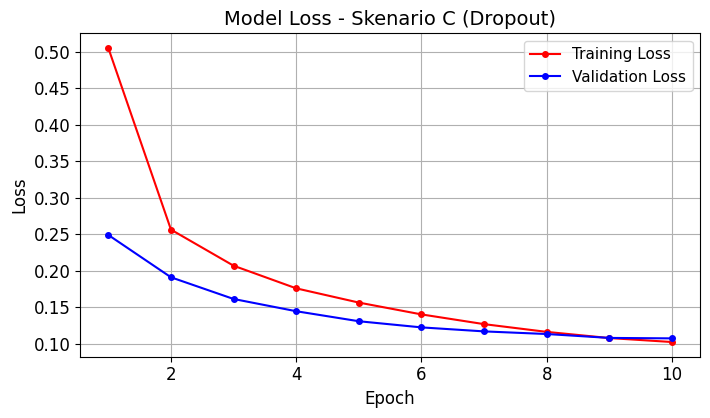

Skenario C - Dropout
Parameter                      : Dropout rate = 0.2
Jumlah epoch yang dijalankan   : 10
Training accuracy (epoch akhir): 96.93%
Validation accuracy (akhir)    : 96.82%
Test accuracy                  : 96.87%
Training accuracy (mode eval)  : 98.33%
Gap train(eval) - validasi     : 1.51 poin persen
Training loss / Val loss / Test loss (akhir): 0.1022 / 0.1072 / 0.1021
Val loss terendah              : 0.1072 (epoch 10)
Total parameters               : 50,890
Trainable parameters           : 50,890
Catatan                        : Training accuracy epoch akhir dihitung saat dropout aktif sehingga cenderung lebih rendah dari akurasi mode eval.



In [8]:
atur_seed()
model_C = Sequential()
model_C.add(Flatten())
model_C.add(Dense(64, activation="relu"))
model_C.add(Dropout(DROPOUT_RATE))
model_C.add(Dense(10, activation="softmax"))
model_C.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["acc"])
model_C.build(input_shape=(None, 28, 28, 1))
ringkasan_model(model_C, "C")

hist_C = model_C.fit(X_train, Y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                     validation_data=(X_val, Y_val))
loss_C, acc_C = model_C.evaluate(X_test, Y_test)
print("Akurasi Testing Skenario C (Dropout):", acc_C)

plot_loss(hist_C, "C", "Skenario C (Dropout)")
simpan_performa("C", "Dropout", model_C, hist_C, loss_C, acc_C,
                parameter=f"Dropout rate = {DROPOUT_RATE}",
                catatan="Training accuracy epoch akhir dihitung saat dropout aktif sehingga cenderung lebih rendah dari akurasi mode eval.")

## 8. Skenario D - Early Stopping
`EarlyStopping(monitor='val_loss', patience=PATIENCE)`; epoch maksimum 50. Sesuai spesifikasi soal,
`restore_best_weights` tidak diaktifkan (default `False`), sehingga bobot akhir adalah bobot pada epoch berhenti.

Model: "sequential_4"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 50,890 (198.79 KB)
 Trainable params: 50,890 (198.79 KB)
 Non-trainable params: 0 (0.00 B)

Epoch 1/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.8838 - loss: 0.4253 - val_acc: 0.9301 - val_loss: 0.2461
Epoch 2/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0

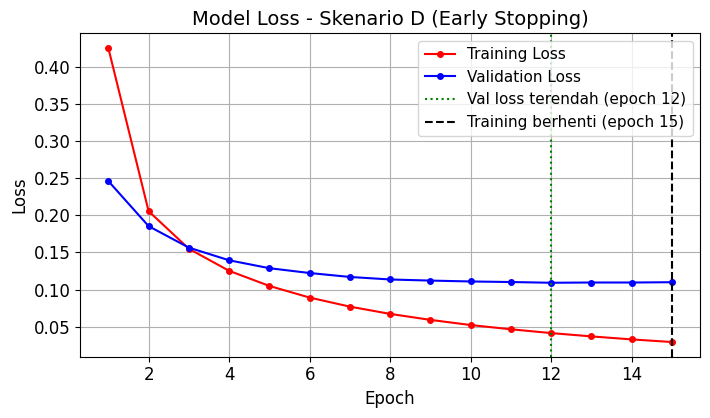

Skenario D - Early Stopping
Parameter                      : patience = 3
Jumlah epoch yang dijalankan   : 15
Training accuracy (epoch akhir): 99.30%
Validation accuracy (akhir)    : 96.84%
Test accuracy                  : 96.90%
Training accuracy (mode eval)  : 99.22%
Gap train(eval) - validasi     : 2.38 poin persen
Training loss / Val loss / Test loss (akhir): 0.0294 / 0.1100 / 0.1053
Val loss terendah              : 0.1092 (epoch 12)
Total parameters               : 50,890
Trainable parameters           : 50,890
Catatan                        : Training berhenti pada epoch 15/50.



In [9]:
atur_seed()
model_D = Sequential()
model_D.add(Flatten())
model_D.add(Dense(64, activation="relu"))
model_D.add(Dense(10, activation="softmax"))
model_D.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["acc"])
model_D.build(input_shape=(None, 28, 28, 1))
ringkasan_model(model_D, "D")

early_stop = EarlyStopping(monitor="val_loss", patience=PATIENCE)
hist_D = model_D.fit(X_train, Y_train, epochs=EPOCHS_ES, batch_size=BATCH_SIZE,
                     validation_data=(X_val, Y_val), callbacks=[early_stop])
loss_D, acc_D = model_D.evaluate(X_test, Y_test)
epoch_berhenti = len(hist_D.history["loss"])
print(f"Training berhenti pada epoch {epoch_berhenti} dari maksimum {EPOCHS_ES}")
print("Akurasi Testing Skenario D (Early Stopping):", acc_D)

plot_loss(hist_D, "D", "Skenario D (Early Stopping)", epoch_berhenti=epoch_berhenti)
simpan_performa("D", "Early Stopping", model_D, hist_D, loss_D, acc_D,
                parameter=f"patience = {PATIENCE}",
                catatan=f"Training berhenti pada epoch {epoch_berhenti}/{EPOCHS_ES}.")

## 9. Skenario E - Kombinasi L1 Regularization + Dropout
Memakai `L1_RATE` dari Skenario A dan `DROPOUT_RATE` dari Skenario C.

Model: "sequential_5"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 50,890 (198.79 KB)
 Trainable params: 50,890 (198.79 KB)
 Non-trainable params: 0 (0.00 B)

Epoch 1/10
490/490 ━━━━━

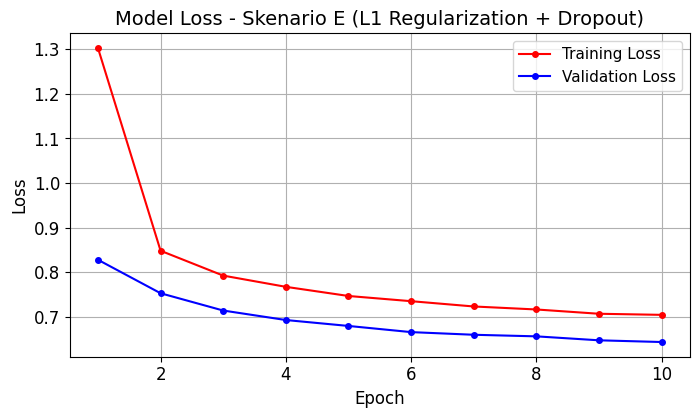

Skenario E - L1 Regularization + Dropout
Parameter                      : L1 rate = 0.001; Dropout rate = 0.2
Jumlah epoch yang dijalankan   : 10
Training accuracy (epoch akhir): 91.36%
Validation accuracy (akhir)    : 93.64%
Test accuracy                  : 93.26%
Training accuracy (mode eval)  : 93.74%
Gap train(eval) - validasi     : 0.10 poin persen
Training loss / Val loss / Test loss (akhir): 0.7050 / 0.6442 / 0.6456
Val loss terendah              : 0.6442 (epoch 10)
Total parameters               : 50,890
Trainable parameters           : 50,890
Catatan                        : Kombinasi konfigurasi Skenario A dan Skenario C.



In [10]:
atur_seed()
model_E = Sequential()
model_E.add(Flatten())
model_E.add(Dense(64, activation="relu", kernel_regularizer=L1(l1=L1_RATE)))
model_E.add(Dropout(DROPOUT_RATE))
model_E.add(Dense(10, activation="softmax", kernel_regularizer=L1(l1=L1_RATE)))
model_E.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["acc"])
model_E.build(input_shape=(None, 28, 28, 1))
ringkasan_model(model_E, "E")

hist_E = model_E.fit(X_train, Y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                     validation_data=(X_val, Y_val))
loss_E, acc_E = model_E.evaluate(X_test, Y_test)
print("Akurasi Testing Skenario E (L1 + Dropout):", acc_E)

plot_loss(hist_E, "E", "Skenario E (L1 Regularization + Dropout)")
simpan_performa("E", "L1 Regularization + Dropout", model_E, hist_E, loss_E, acc_E,
                parameter=f"L1 rate = {L1_RATE}; Dropout rate = {DROPOUT_RATE}",
                catatan="Kombinasi konfigurasi Skenario A dan Skenario C.")

## 10. Tabel perbandingan seluruh skenario
Kriteria overfitting: **gap** = akurasi training (mode eval) - akurasi validasi. Dianggap overfitting ("Ya") bila gap >= 1,0 poin persen.

In [11]:
urutan = ["Baseline", "A", "B", "C", "D", "E"]
baris = [f"{'Skenario':10s}{'Parameter':32s}{'Train':>8s}{'Val':>8s}{'Test':>8s}{'Gap(pp)':>9s}  Overfit?"]
for k in urutan:
    d = HASIL[k]
    baris.append(f"{k:10s}{d['parameter']:32s}{d['train_acc']*100:7.2f}%{d['val_acc']*100:7.2f}%"
                 f"{d['test_acc']*100:7.2f}%{d['gap_pp']:9.2f}  {'Ya' if d['gap_pp'] >= 1.0 else 'Tidak'}")
tabel = "\n".join(baris)
print(tabel)
with open(f"{HASIL_DIR}/Tabel_Perbandingan.txt", "w", encoding="utf-8") as f:
    f.write(tabel + "\n")
with open(f"{HASIL_DIR}/hasil_semua_skenario.json", "w", encoding="utf-8") as f:
    json.dump(HASIL, f, indent=2, ensure_ascii=False)

Skenario  Parameter                          Train     Val    Test  Gap(pp)  Overfit?
Baseline  -                                 98.59%  96.62%  96.94%     1.94  Ya
A         L1 rate = 0.001                   93.57%  93.42%  93.26%     0.31  Tidak
B         L2 rate = 0.001                   96.69%  95.94%  96.23%     1.11  Ya
C         Dropout rate = 0.2                96.93%  96.82%  96.87%     1.51  Ya
D         patience = 3                      99.30%  96.84%  96.90%     2.38  Ya
E         L1 rate = 0.001; Dropout rate = 0.2  91.36%  93.64%  93.26%     0.10  Tidak
